# Keşifsel Veri Analizi (EDA)

**Amaç:** Sentetik verinin gerçekçi olup olmadığını karar verilebilir hale getirmek.
Bu defter bir rapor değil, bir **kontrol noktasıdır**: veri burada gerçekçi görünmüyorsa
`src/data/generator.py`'a dönülür. Plan gereği veriye **Gün 5'ten sonra dokunulmaz**,
çünkü model ve etiket kalibrasyonu onun üstüne kurulur.

Kontrol edilecek beş şey:

1. Müşteri profili dağılımları makul mü
2. İşlem yoğunluğu harcama analizini (PFM) taşıyor mu
3. Kategori dağılımı TCMB hedefine oturuyor mu, mevsimsellik görünüyor mu
4. `analyze_spending`'in bulacağı sinyaller (düzenli gider, olağandışı artış) veride var mı
5. Kabul etiketi basit bir kuralı ezberletiyor mu

In [1]:
import sys
from pathlib import Path

KOK = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(KOK))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.config import load_config, resolve_path
from src.data.source import build_data_source

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.titlesize"] = 11

config = load_config()
source = build_data_source(config)

musteriler = source.get_customers()
islemler = source.get_transactions()
kampanyalar = source.get_campaigns()
etkilesimler = source.get_interactions()

islemler["ay"] = islemler["transaction_date"].dt.to_period("M")
as_of = islemler["transaction_date"].max()

print(f"müşteri     : {len(musteriler):,}")
print(f"işlem       : {len(islemler):,}")
print(f"kampanya    : {len(kampanyalar):,}")
print(f"etkileşim   : {len(etkilesimler):,}")
print(f"veri aralığı: {islemler['transaction_date'].min().date()} → {as_of.date()}")

Matplotlib is building the font cache; this may take a moment.


müşteri     : 2,000
işlem       : 362,009
kampanya    : 14
etkileşim   : 7,857
veri aralığı: 2025-09-01 → 2026-08-13


## 1. Müşteri profili

Beklenen: mass ağırlıklı bir taban, gelir bandı segmentle ilişkili ama birebir değil,
yaş dağılımı tek tepeli değil (arkada birden fazla persona var).

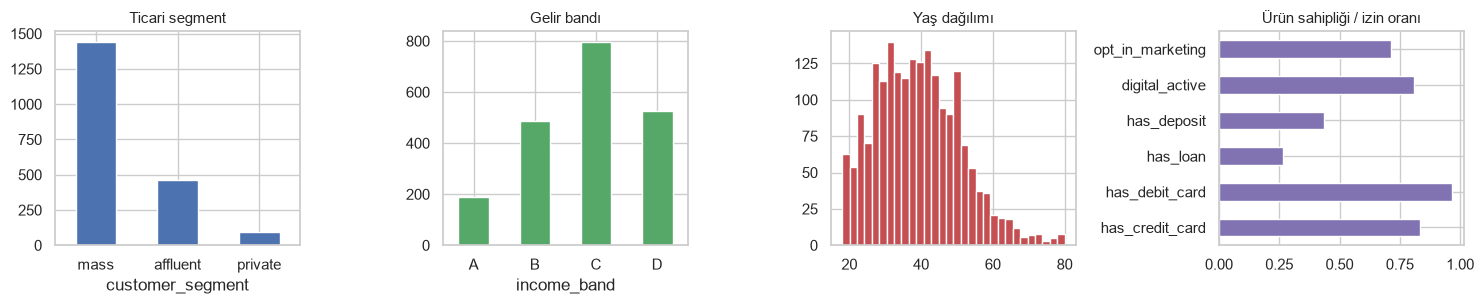

income_band          A     B     C     D
customer_segment                        
affluent          0.19  0.49  0.30  0.01
mass              0.02  0.16  0.46  0.36
private           0.79  0.20  0.01  0.00


In [2]:
fig, eksen = plt.subplots(1, 4, figsize=(15, 3.2))

musteriler["customer_segment"].value_counts().plot.bar(ax=eksen[0], color="#4C72B0")
eksen[0].set_title("Ticari segment")

musteriler["income_band"].value_counts().sort_index().plot.bar(ax=eksen[1], color="#55A868")
eksen[1].set_title("Gelir bandı")

eksen[2].hist(musteriler["age"], bins=30, color="#C44E52")
eksen[2].set_title("Yaş dağılımı")

urunler = musteriler[["has_credit_card", "has_debit_card", "has_loan",
                      "has_deposit", "digital_active", "opt_in_marketing"]].mean()
urunler.plot.barh(ax=eksen[3], color="#8172B2")
eksen[3].set_title("Ürün sahipliği / izin oranı")

for e in eksen[:2]:
    e.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print(pd.crosstab(musteriler["customer_segment"], musteriler["income_band"],
                  normalize="index").round(2).to_string())

**Yaş dağılımının çok tepeli olması kasıtlıdır.** Arkada beş gizli persona var
(dijital genç, aile-market odaklı, seyahat eden affluent, araç sahibi çalışan,
temkinli tasarrufçu) ve her birinin yaş profili farklı. Persona bilgisi **veriye
hiç yazılmaz** — Gün 4'te KMeans'in bulması gereken yapı budur.

## 2. İşlem yoğunluğu — PFM anlatısını taşıyor mu?

Kritik eşik: müşteri başına **son 30 günde** kaç işlem ve kaç dolu kategori var?
"Geçen ay nereye harcadım?" sorusunun cevabı 3 dolu 9 boş kategori olursa
harcama analizi aracının söyleyecek bir şeyi olmaz.

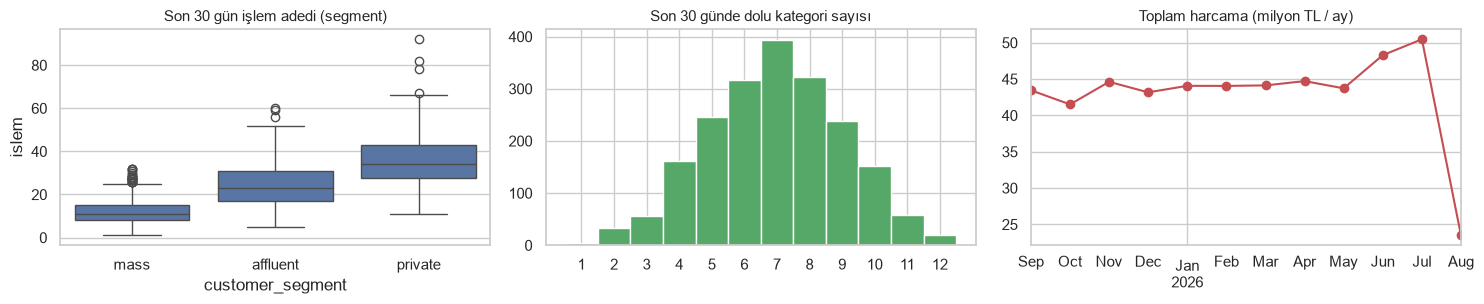

                  islem  kategori
customer_segment                 
affluent           24.5       8.6
mass               11.7       6.2
private            36.7       9.8

Müşterilerin %75'ünde son 30 günde >= 6 dolu kategori


In [3]:
son30 = islemler[islemler["transaction_date"] >= as_of - pd.Timedelta(days=30)]
ozet = (
    son30.groupby("customer_id")
    .agg(islem=("amount", "size"), kategori=("mcc_category", "nunique"))
    .join(musteriler.set_index("customer_id")["customer_segment"])
)

fig, eksen = plt.subplots(1, 3, figsize=(15, 3.2))
sns.boxplot(data=ozet, x="customer_segment", y="islem", ax=eksen[0],
            order=["mass", "affluent", "private"])
eksen[0].set_title("Son 30 gün işlem adedi (segment)")

eksen[1].hist(ozet["kategori"], bins=range(1, 14), color="#55A868", align="left")
eksen[1].set_title("Son 30 günde dolu kategori sayısı")
eksen[1].set_xticks(range(1, 13))

aylik = islemler.groupby("ay")["amount"].sum() / 1e6
aylik.plot(ax=eksen[2], marker="o", color="#C44E52")
eksen[2].set_title("Toplam harcama (milyon TL / ay)")
eksen[2].set_xlabel("")

plt.tight_layout()
plt.show()

print(ozet.groupby("customer_segment")[["islem", "kategori"]].mean().round(1).to_string())
print(f"\nMüşterilerin %{(ozet['kategori'] >= 6).mean()*100:.0f}'ünde son 30 günde >= 6 dolu kategori")

> **Bu grafik bir düzeltmenin sonucu.** İlk `config.yaml` ayda 6 işlem üretiyordu;
> son 30 günde 12 kategoriden ancak 3'ü doluyordu. Segment bazlı hıza geçildi
> (mass 10 / affluent 22 / private 35). Son aydaki düşüş kısmi aydan kaynaklanıyor —
> veri ayın ortasında bitiyor, eksiklik değil.

## 3. Kategori dağılımı ve mevsimsellik

Kategori payları TCMB "Banka ve Kredi Kartı Sektörel Harcama İstatistikleri"nden
türetilen hedeflere kalibre edildi. "Dağılımı uydurmadım, kaynağa kalibre ettim"
cümlesi sentetik veri savunmasının en güçlü parçası — ama ancak tutarsa.

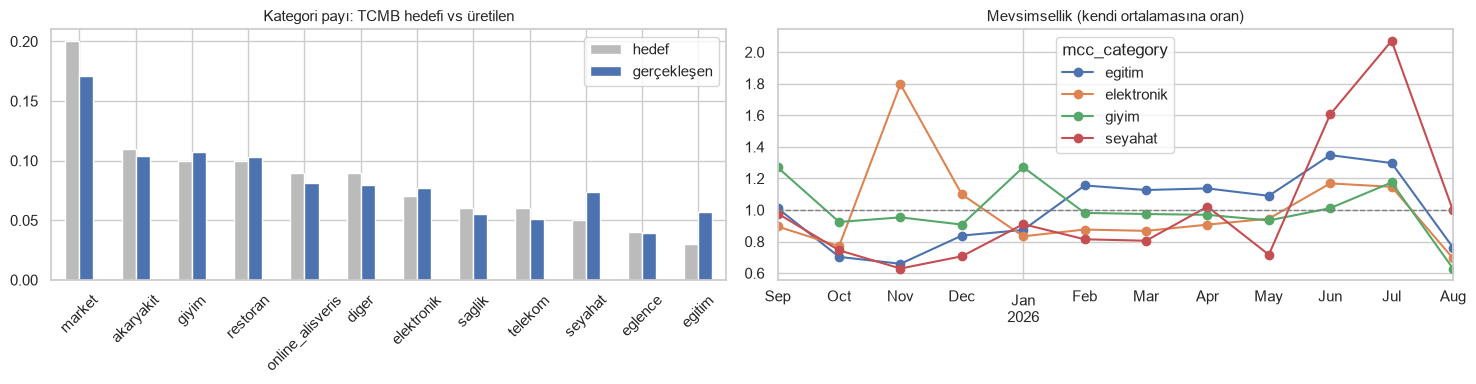

                  hedef  gerçekleşen   fark
market             0.20        0.171 -0.029
akaryakit          0.11        0.104 -0.006
giyim              0.10        0.108  0.008
restoran           0.10        0.103  0.003
online_alisveris   0.09        0.082 -0.008
diger              0.09        0.079 -0.011
elektronik         0.07        0.077  0.007
saglik             0.06        0.055 -0.005
telekom            0.06        0.051 -0.009
seyahat            0.05        0.074  0.024
eglence            0.04        0.040 -0.000
egitim             0.03        0.057  0.027

En büyük sapma: 2.9%


In [4]:
hedef = pd.Series(config["generator"]["category_weights"], name="hedef")
gercek = islemler.groupby("mcc_category")["amount"].sum()
gercek = (gercek / gercek.sum()).rename("gerçekleşen")
kiyas = pd.concat([hedef, gercek], axis=1).sort_values("hedef", ascending=False)

fig, eksen = plt.subplots(1, 2, figsize=(15, 4))
kiyas.plot.bar(ax=eksen[0], color=["#BBBBBB", "#4C72B0"])
eksen[0].set_title("Kategori payı: TCMB hedefi vs üretilen")
eksen[0].tick_params(axis="x", rotation=45)

mevsim = (
    islemler[islemler["mcc_category"].isin(["giyim", "seyahat", "egitim", "elektronik"])]
    .pivot_table(index="ay", columns="mcc_category", values="amount", aggfunc="sum")
)
(mevsim / mevsim.mean()).plot(ax=eksen[1], marker="o")
eksen[1].axhline(1.0, color="gray", linestyle="--", linewidth=1)
eksen[1].set_title("Mevsimsellik (kendi ortalamasına oran)")
eksen[1].set_xlabel("")

plt.tight_layout()
plt.show()

kiyas["fark"] = kiyas["gerçekleşen"] - kiyas["hedef"]
print(kiyas.round(3).to_string())
print(f"\nEn büyük sapma: {kiyas['fark'].abs().max():.1%}")

> **Burada da bir hata yakalandı.** `category_weights` TCMB'de *tutar* payıdır;
> üreteç başlangıçta bunu doğrudan işlem seçim olasılığı olarak kullanıyordu.
> Seyahat/elektronik sepeti markete göre ~9 kat büyük olduğu için seyahat %5 hedefe
> karşı **%26** çıkmıştı. Düzeltme: adet olasılığı `pay / ortalama_sepet` ile türetilir.
>
> Mevsimsellik grafiği kampanya kataloğuyla uyumlu olmalı: `KMP007` sezon sonu giyim
> kampanyası 5 Ağustos–20 Eylül arasında ve giyim harcaması tam o dönemde tepe yapıyor.

## 4. PFM sinyalleri

`analyze_spending` (Gün 6) iki şey arayacak: **düzenli giderler** ve **olağandışı
artışlar**. Veri bunları içermiyorsa araç boş çıktı verir. Eşikler
`config.yaml → agent.spending_analysis` altında.

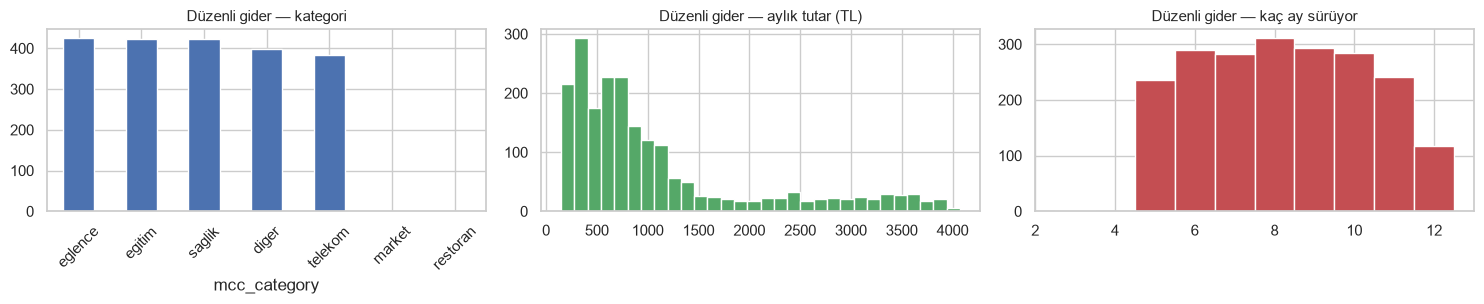

Düzenli gideri tespit edilebilen müşteri : %65
Ortalama aylık tutar                     : 1,088 TL

NOT: %100 OLMAMASI istenir — düzenli gideri olmayan müşteri,
Gün 6 testinin 'boş liste dönmeli' negatif vakasıdır.


In [5]:
esik = config["agent"]["spending_analysis"]
alt, ust = esik["recurring_gap_days"]

# --- düzenli gider: aynı üye işyeri, ayda tek, tutar oynaması küçük, düzenli aralık
aylik_uye = (
    islemler.groupby(["customer_id", "merchant_id", "ay"])
    .agg(tutar=("amount", "sum"), adet=("amount", "size"), ilk=("transaction_date", "min"))
    .reset_index().sort_values(["customer_id", "merchant_id", "ay"])
)
fark = aylik_uye.groupby(["customer_id", "merchant_id"])["ilk"].diff().dt.days
aylik_uye["aralik_ok"] = fark.isna() | fark.between(alt, ust)

ozet_uye = aylik_uye.groupby(["customer_id", "merchant_id"]).agg(
    ay=("tutar", "size"), tmin=("tutar", "min"), tmax=("tutar", "max"),
    tort=("tutar", "mean"), adet_max=("adet", "max"), aralik_ok=("aralik_ok", "all"),
)
duzenli = ozet_uye[
    (ozet_uye["ay"] >= esik["recurring_min_months"])
    & (ozet_uye["adet_max"] == 1)
    & (((ozet_uye["tmax"] - ozet_uye["tmin"]) / ozet_uye["tort"]) <= esik["recurring_amount_tolerance"])
    & ozet_uye["aralik_ok"]
].reset_index()

fig, eksen = plt.subplots(1, 3, figsize=(15, 3.2))
duzenli.merge(islemler[["merchant_id", "mcc_category"]].drop_duplicates(),
              on="merchant_id")["mcc_category"].value_counts().plot.bar(
    ax=eksen[0], color="#4C72B0")
eksen[0].set_title("Düzenli gider — kategori")
eksen[0].tick_params(axis="x", rotation=45)

eksen[1].hist(duzenli["tort"], bins=30, color="#55A868")
eksen[1].set_title("Düzenli gider — aylık tutar (TL)")

eksen[2].hist(duzenli["ay"], bins=range(3, 14), color="#C44E52", align="left")
eksen[2].set_title("Düzenli gider — kaç ay sürüyor")

plt.tight_layout()
plt.show()

kapsam = duzenli["customer_id"].nunique() / musteriler["customer_id"].nunique()
print(f"Düzenli gideri tespit edilebilen müşteri : %{kapsam*100:.0f}")
print(f"Ortalama aylık tutar                     : {duzenli['tort'].mean():,.0f} TL")
print("\nNOT: %100 OLMAMASI istenir — düzenli gideri olmayan müşteri,")
print("Gün 6 testinin 'boş liste dönmeli' negatif vakasıdır.")

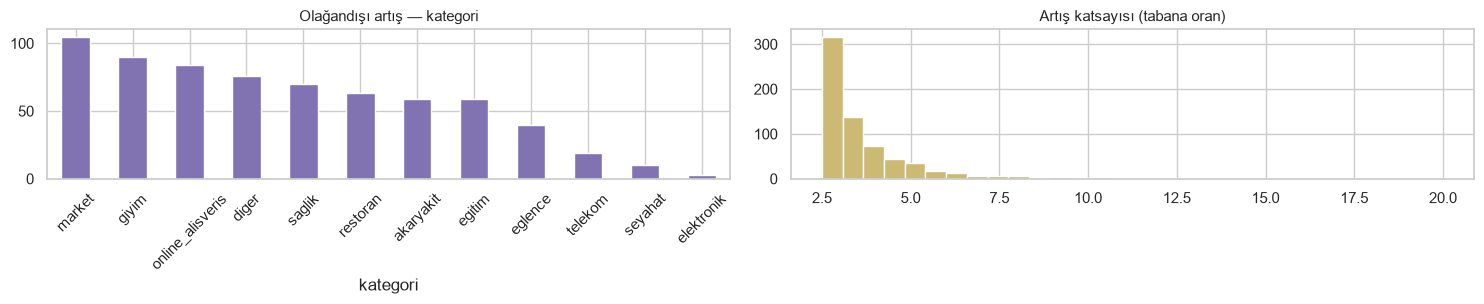

Sıçrama tespit edilen müşteri: %25  (üreteç %20'sine ekiyor)

DÖRT şart birden aranıyor. Sadece '2.5 kat' kuralı uygulansaydı
müşterilerin %96'sı işaretlenirdi: seyrek kategoride ayda tek işlem
doğal olarak zıplar. %96 uyarı vermek, hiç uyarı vermemekle aynı şeydir.


In [6]:
# --- olağandışı artış: son 3 ayın her biri, kendinden önceki 3 aya karşı
son_aylar = sorted(islemler["ay"].unique())[-3:]
pivot = islemler.pivot_table(index=["customer_id", "ay"], columns="mcc_category",
                             values="amount", aggfunc="sum").fillna(0.0)

bulgular = []
for cid, g in pivot.groupby(level=0):
    g = g.droplevel(0)
    for ay in son_aylar:
        if ay not in g.index:
            continue
        onceki = g.loc[g.index < ay].tail(esik["anomaly_baseline_months"])
        if len(onceki) < esik["anomaly_baseline_months"]:
            continue
        for kat in g.columns:
            if esik["anomaly_require_full_baseline"] and (onceki[kat] == 0).any():
                continue
            son, taban = g.loc[ay, kat], onceki[kat].mean()
            if (taban >= esik["anomaly_min_baseline"]
                    and son >= taban * esik["anomaly_ratio_threshold"]
                    and son - taban >= esik["anomaly_min_amount"]):
                bulgular.append({"customer_id": cid, "kategori": kat,
                                 "ay": str(ay), "kat": son / taban})

anomali = pd.DataFrame(bulgular)
fig, eksen = plt.subplots(1, 2, figsize=(15, 3.2))
anomali["kategori"].value_counts().plot.bar(ax=eksen[0], color="#8172B2")
eksen[0].set_title("Olağandışı artış — kategori")
eksen[0].tick_params(axis="x", rotation=45)
eksen[1].hist(anomali["kat"].clip(upper=20), bins=30, color="#CCB974")
eksen[1].set_title("Artış katsayısı (tabana oran)")
plt.tight_layout()
plt.show()

oran = anomali["customer_id"].nunique() / len(musteriler)
print(f"Sıçrama tespit edilen müşteri: %{oran*100:.0f}  (üreteç %20'sine ekiyor)")
print("\nDÖRT şart birden aranıyor. Sadece '2.5 kat' kuralı uygulansaydı")
print("müşterilerin %96'sı işaretlenirdi: seyrek kategoride ayda tek işlem")
print("doğal olarak zıplar. %96 uyarı vermek, hiç uyarı vermemekle aynı şeydir.")

## 5. Kabul etiketi — döngüsellik tuzağı

`accepted` basit bir kuralla üretilseydi model kuralı ezberler, AUC ~0.99 çıkardı
ve bu bir sonuç değil ölçüm hatası olurdu. Etiket; kategori uyumu, kampanya cazibesi,
kanal uyumu ve asgari harcama sürtünmesinin yanında **özellik tablosuna girmeyen
gizli bir müşteri eğilimi** ile üretiliyor.

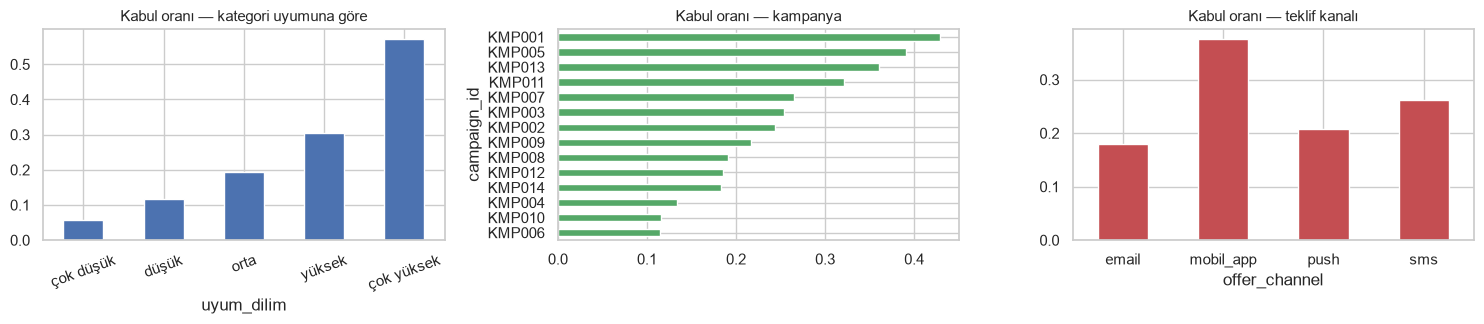

Genel kabul oranı: %24.9
Kampanya bazında  : %11 – %43

Hiçbir kampanya %0 veya %100 değil: etiket determinist bir kural değil.
Uyum arttıkça kabul artıyor ama tek başına belirlemiyor — aradaki boşluk
gizli eğilim ve gürültü, yani modelin ulaşamayacağı tavan.


In [7]:
# Kategori uyumu ile kabul oranı arasındaki ilişki gerçekten var mı?
paylar = islemler.pivot_table(index="customer_id", columns="mcc_category",
                              values="amount", aggfunc="sum").fillna(0.0)
paylar = paylar.div(paylar.sum(axis=1), axis=0)
hedef_kat = kampanyalar.set_index("campaign_id")["target_categories"].to_dict()

e = etkilesimler.copy()
e["uyum"] = [
    sum(paylar.loc[c, k] for k in hedef_kat[kmp] if k in paylar.columns)
    if c in paylar.index else 0.0
    for c, kmp in zip(e["customer_id"], e["campaign_id"])
]
e["uyum_dilim"] = pd.qcut(e["uyum"], 5, labels=["çok düşük", "düşük", "orta", "yüksek", "çok yüksek"])

fig, eksen = plt.subplots(1, 3, figsize=(15, 3.4))
e.groupby("uyum_dilim", observed=True)["accepted"].mean().plot.bar(ax=eksen[0], color="#4C72B0")
eksen[0].set_title("Kabul oranı — kategori uyumuna göre")
eksen[0].tick_params(axis="x", rotation=20)

kmp = e.groupby("campaign_id")["accepted"].agg(["mean", "size"]).sort_values("mean")
kmp["mean"].plot.barh(ax=eksen[1], color="#55A868")
eksen[1].set_title("Kabul oranı — kampanya")

e.groupby("offer_channel")["accepted"].mean().plot.bar(ax=eksen[2], color="#C44E52")
eksen[2].set_title("Kabul oranı — teklif kanalı")
eksen[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print(f"Genel kabul oranı: %{e['accepted'].mean()*100:.1f}")
print(f"Kampanya bazında  : %{kmp['mean'].min()*100:.0f} – %{kmp['mean'].max()*100:.0f}")
print("\nHiçbir kampanya %0 veya %100 değil: etiket determinist bir kural değil.")
print("Uyum arttıkça kabul artıyor ama tek başına belirlemiyor — aradaki boşluk")
print("gizli eğilim ve gürültü, yani modelin ulaşamayacağı tavan.")

## 6. Özellik tablosu ve davranışsal segmentler

`python -m src.features.build` ve `python -m src.models.segmentation` çalıştırılmış olmalı.

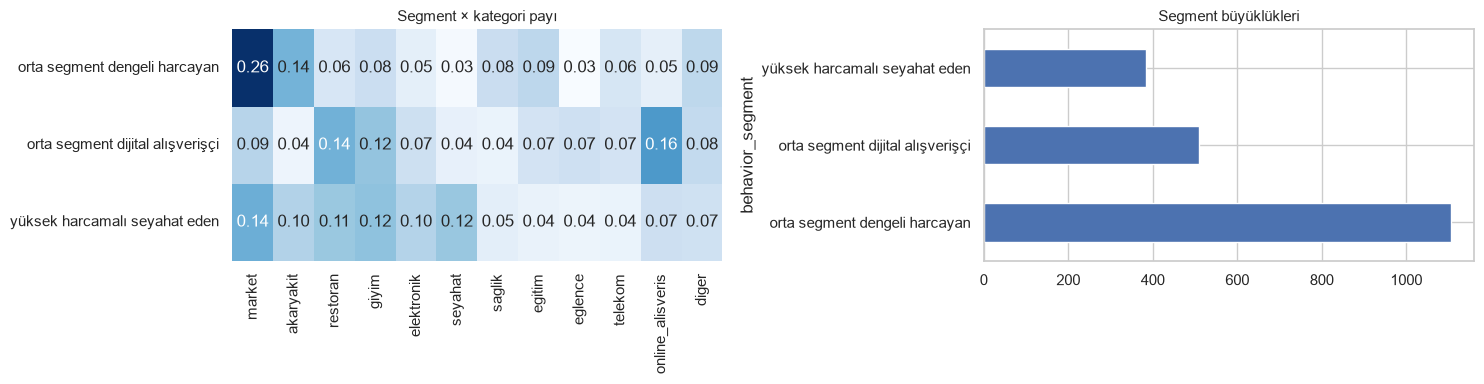

                                  musteri  yillik_harcama  online_payi  taksit_orani
behavior_segment                                                                    
orta segment dengeli harcayan        1105       159433.29         0.21          0.04
orta segment dijital alışverişçi      510       165435.83         0.36          0.07
yüksek harcamalı seyahat eden         385       662685.89         0.31          0.11

Ticari segment ile davranışsal segment aynı şey DEĞİL:
customer_segment                  affluent  mass  private
behavior_segment                                         
orta segment dengeli harcayan         0.15  0.84     0.01
orta segment dijital alışverişçi      0.14  0.85     0.01
yüksek harcamalı seyahat eden         0.58  0.21     0.21


In [8]:
islenmis = resolve_path(config["data"]["processed_dir"])
ozellikler = pd.read_parquet(islenmis / "customer_features.parquet")
segmentler = pd.read_parquet(islenmis / "customer_segments.parquet")
birlesik = ozellikler.merge(segmentler, on="customer_id")

pay_kolon = [c for c in ozellikler.columns if c.startswith("cat_share_")]
profil = birlesik.groupby("behavior_segment")[pay_kolon].mean()
profil.columns = [c.replace("cat_share_", "") for c in profil.columns]

fig, eksen = plt.subplots(1, 2, figsize=(15, 4))
sns.heatmap(profil, annot=True, fmt=".2f", cmap="Blues", ax=eksen[0], cbar=False)
eksen[0].set_title("Segment × kategori payı")
eksen[0].set_ylabel("")

birlesik["behavior_segment"].value_counts().plot.barh(ax=eksen[1], color="#4C72B0")
eksen[1].set_title("Segment büyüklükleri")
plt.tight_layout()
plt.show()

print(birlesik.groupby("behavior_segment").agg(
    musteri=("customer_id", "size"),
    yillik_harcama=("monetary_total", "mean"),
    online_payi=("channel_share_online", "mean"),
    taksit_orani=("installment_ratio", "mean"),
).round(2).to_string())

print("\nTicari segment ile davranışsal segment aynı şey DEĞİL:")
print(pd.crosstab(birlesik["behavior_segment"], birlesik["customer_segment"],
                  normalize="index").round(2).to_string())

## Bulgular ve alınan aksiyonlar

EDA bir rapor değil kontrol noktası olduğu için, bulunan her sorun `generator.py`
veya `config.yaml` üzerinde düzeltildi:

| Bulgu | Aksiyon |
|---|---|
| Ayda 6 işlem → son 30 günde 12 kategoriden 3'ü dolu | Segment bazlı hız (10/22/35), ~366k işlem |
| Seyahat payı %5 hedefe karşı %26 | Adet olasılığı = tutar payı / ortalama sepet |
| Etiket tavanı AUC 0.857 (bant üstü) | `W_LATENT` 1.3 → 2.0, tavan 0.787 |
| "2.5 kat" anomali kuralı müşterilerin %96'sını işaretliyor | Dört şartlı kural, %24'e indi |
| Taksitli işlem %1.8, müşteriler arası ayrım yok | Müşteriye özgü gizli taksit eğilimi, %6'ya çıktı |
| `recency_days` ortalaması 1,8 gün — ayırt edici değil | Kümelemeden çıkarıldı, modelde kaldı |
| KMeans k=5'te 23 kişilik artık küme | En küçük küme ≥ %5 kısıtı, k=3 seçildi |

**Veri artık dondurulmuş sayılır.** Plan gereği Gün 5'ten sonra üretece dönülmez;
propensity modelinin metrikleri bu veri üzerinde anlamlıdır.